In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import anndata as ad
import squidpy as sq
 
import pickle


# Load final version

In [3]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "supp"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))


In [4]:
#PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.addrelapse'
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_inc_relapse_webportal.h5ad'

adata=sc.read_h5ad(PATH)
adata=adata[adata.obs["all_vs_core"]!="relapse"]

In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


In [6]:
adata_b=  adata[adata.obs["Site_status"].str.startswith("PostRx")].copy()
adata_b=adata_b[adata_b.obs["lvl5_annotation"].isin(["ILC2", "ILC3", "ILC3_CCL1+PTGDS+", "TRM_IL13+"])]
adata_b

View of AnnData object with n_obs × n_vars = 2748 × 4993
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'dataset_id', 'lvl5_annotation', 'Mapping_status', 'scanvi_predictions', 'atlas_status_reynolds', 'atlas_status_simple', 'cell_id', 'x_centroid', 'y_centroid', 'Sanger patient ID', 'Timepoint', 'disease_overall', 'lvl0_new', 'Timepoint2', 'info_id6', 'response', 'all_vs_core', 'tech', 'scanvi_predictions2', 'lvl1_new', 'niche19', 'data_addition', 'fig1a_numbers_scrna', 'fig1_numbers_xenium_without_validation_data', 'Site_status2', 'tmp', 'lvl0'
    uns: 'lvl5_annotation_colors', 'niche19_colors', 'tech_colors', 'log1p'
    obsm: 'X_scanvi', 'X_umap', 'spatial'

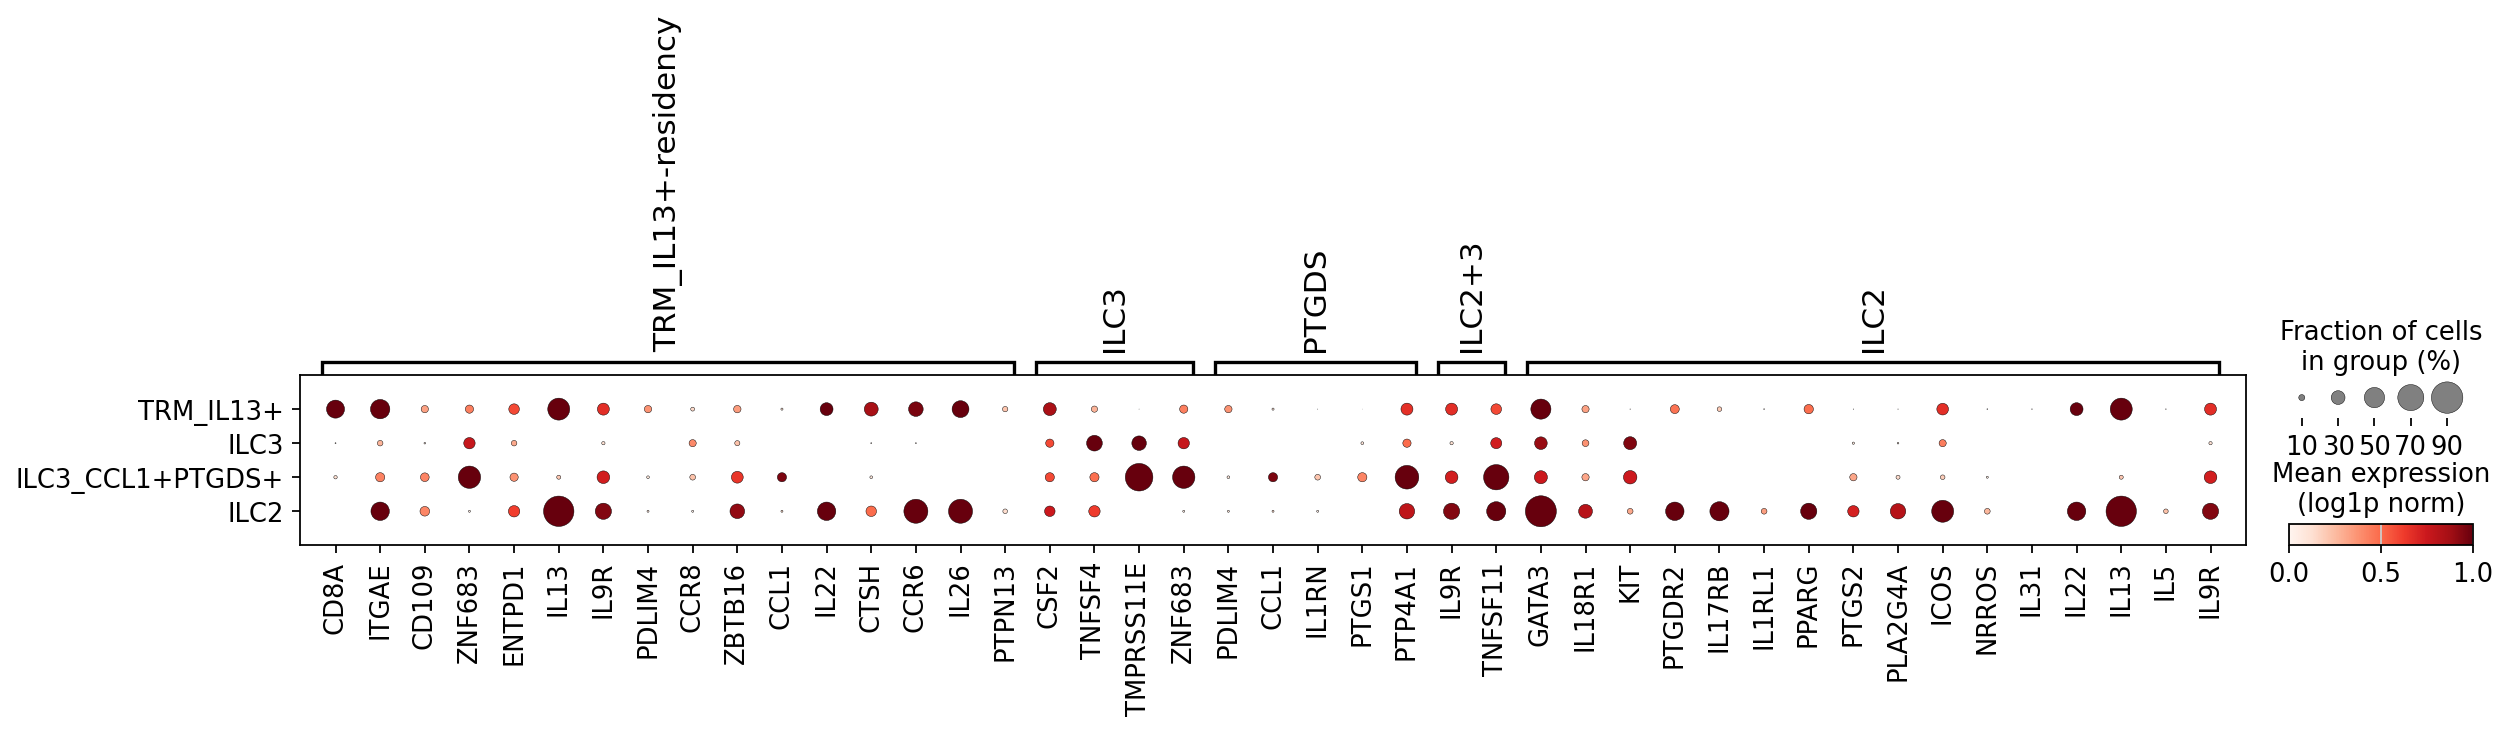

In [7]:
MARKERS2 = {
        'TRM_IL13+-residency': ['CD8A', 'ITGAE', 'CD109', 'ZNF683', 'ENTPD1', 'IL13', 'NBAS',# 'CCL17',
         'AREG', 'IL9R', 'PDLIM4', 'CCR8',
         'ZBTB16', 'KLRC4', 'ADGRG1', 'RGS9', 'KRT7', "CCL1" ,'IL22', 

  'CTSH',

  'CCR6',
  'IL26', 'PTPN13',
         ],  
          'ILC3': ['ID3','CSF2', 'KRT86',
 # 'ZBTB46',
  'TNFSF4',
  'SPINK2',
  'RAMP1',
  'MB',
  'KLRF2',
  'TMPRSS11E', "ZNF683"],
           'PTGDS': [  'PTGDS', 'PDLIM4', 'CCL1', 'IL1RN', 'PTGS1', 'PTP4A1'],


 'ILC2+3': ['IL9R', 'TNFSF11'],
 'ILC2': ['GATA3',  'IL18R1','KIT', 'PTGDR2', 'TNFRSF25',
          'CRLF2',
  'IL17RB',
  'IL1RL1',

  'PPARG',
  'PTGS2',
  'PLA2G4A',
  #'IL4',

  'ICOS',
  'NRROS',     'IL31',
'IL22', 'IL13', "IL5",#'PDLIM4', 'CCL1',
          #'AREG', 'CCR8',
          'IL9R'],
 # 'Naive/Tcm': ['SELL', 'CCR7', 'S1PR1', 'TCF7', 'PAK2', 'ZHX2'],
 #        "NEW": ["PLXDC2", "AIF1", "RAB34", "NEDD4L", "PM20D2", "TNRC18", "JCHAIN", ],
 # 'Cycling': ['UBE2C', 'MKI67', 'TOP2A'],
 #        "RORC+": ["RORC",]
        }
MIN_N = 1


def remove_markers(markers, adata):
    return {
        k: [g for g in v if g in adata.var_names]
        for k, v in markers.items()
    }

# --------------------------
def add_final_with_n(adata, min_n=20):
    vc = adata.obs["lvl5_annotation"].value_counts()
    keep = vc[vc >= min_n].index

    adata.obs["final_filtered"] = (
        adata.obs["lvl5_annotation"]
        .where(adata.obs["lvl5_annotation"].isin(keep))
        .astype("category")
    )

    vc = adata.obs["final_filtered"].value_counts()

    adata.obs["final_with_n"] = (
        adata.obs["final_filtered"]
        .astype(str)
        .map(lambda x: f"{x}_n={vc[x]}" if x != "nan" else None)
        .astype("category")
    )

sc.pl.dotplot(
    adata_b,
    remove_markers(MARKERS2, adata_b),
    groupby="lvl5_annotation",
    dendrogram=False,
    vmax=1,
    categories_order=['TRM_IL13+','ILC3', 'ILC3_CCL1+PTGDS+', 'ILC2', ],
    colorbar_title="Mean expression\n(log1p norm)",
                save=f"BANGERT_dotplot_scrna.pdf"

) 


In [8]:
adata_b.obs["lvl5_annotation"].unique()

['TRM_IL13+', 'ILC2', 'ILC3', 'ILC3_CCL1+PTGDS+']
Categories (4, object): ['ILC2', 'ILC3', 'ILC3_CCL1+PTGDS+', 'TRM_IL13+']

In [9]:

adata=adata[adata.obs["lvl5_annotation"].str.startswith('TRM')].copy()
import gc
gc.collect()
def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST



In [10]:
adata_5k=adata[adata.obs["tech"]=='xenium'].copy()
adata_scrna=adata[adata.obs["tech"]!='xenium'].copy()

In [11]:
MARKERS = {"CD8/CD4": ['CD8A', "CD4"],
        'Tissue-residency': ['ITGAE', 'CD109', 'ZNF683', 'ENTPD1'],
 'TRM_IL13': [ 'IL13', 'NBAS',# 'CCL17',
         'AREG', 'IL9R', 'PDLIM4', 
         'ZBTB16', 'KLRC4', 'ADGRG1', 'RGS9', 'KRT7', "CCL1", "CCR8" ],
 'TRM_IL17': ['IL17A',
  'IL17F',
  'CXCL13',
  'CCL20',
  'IL23R',
  'RORC',
  'ADAM12',  'LRRN3',
  'MYO7A',
  'IL21',  ],
    'Mixed': ['VDR','IL22', 

  'CTSH',

  'CCR6',
  'IL26', 'PTPN13',
         ],  
       
#  'Tissue-residency\n markers': ['CD8A', 'ITGAE', 'CD109', 'ZNF683', 'ENTPD1'],
#  'TRM_IL13': ['IL22', 'IL13', 'NBAS',# 'CCL17',
#          'AREG', 'IL9R', 'PDLIM4', 'CCR8',
#          'ZBTB16', 'KLRC4', 'ADGRG1', 'RGS9'],
#  'TRM_IL17': ['IL17A',
#   'IL17F',
#   'CXCL13',
#   'CCL20',
#   'IL23R',
#   'RORC',
#   'ADAM12',  'LRRN3',
#   'MYO7A',
#   'IL21',],
#     'Mixed': [

#   'CTSH',
#   'VDR',
#   'CCR6',
#   'IL26'
#          ],
#  'Other': ['PTPN13', #'ITGA1'
#           ],
#  'ITGA1hi': ['ITGA1', 'ZHX2', 'BICD1', 'PRR5L', 'ST8SIA1', 'ZNF407', "KLRG1"],
          }

In [12]:
adata_scrna.obs["Site_status2"]=adata_scrna.obs["lvl5_annotation"].astype(str)+"_"+adata_scrna.obs["Site_status"].astype(str)
[x for x in adata_scrna.obs["Site_status2"].unique()]

['TRM_IL13+_Non-lesional',
 'TRM_IL17+_Non-lesional',
 'TRM_IL13+_Lesional',
 'TRM_IL17+_Lesional',
 'TRM_IL13+_PostRx',
 'TRM_IL17+_PostRx',
 'TRM_IL17+_Healthy',
 'TRM_IL13+_Healthy',
 'TRM_IL13+_PostRx-Lesional Dupilumab (16 wk)',
 'TRM_IL17+_PostRx-Lesional Dupilumab (16 wk)',
 'TRM_IL13+_PostRx-Lesional Dupilumab (1 yr)',
 'TRM_IL17+_PostRx-Lesional Dupilumab (1 yr)']

In [13]:
KEEP = ['TRM_IL13+_Non-lesional',
 'TRM_IL17+_Non-lesional',
 'TRM_IL13+_Lesional',
 'TRM_IL17+_Lesional',
 #'TRM_IL13+_PostRx',
 #'TRM_IL17+_PostRx',
 ##'TRM_IL17+_Healthy',
 ##'TRM_IL13+_Healthy',
 #'TRM_IL13+_PostRx-Lesional Dupilumab (16 wk)',
 #'TRM_IL17+_PostRx-Lesional Dupilumab (16 wk)',
 ##'TRM_IL13+_PostRx-Lesional Dupilumab (1 yr)',
 #'TRM_IL17+_PostRx-Lesional Dupilumab (1 yr)'
]
adata_scrna=adata_scrna[adata_scrna.obs["Site_status2"].isin(KEEP)]


In [14]:
mask_pso = (
    (adata_scrna.obs["Patient_status"] == "Psoriasis") &
    (adata_scrna.obs["Site_status2"].isin(["TRM_IL17+_Lesional", "TRM_IL17+_Non-lesional"]))
)

mask_ad = (
    (adata_scrna.obs["Patient_status"] == "AD") &
    (adata_scrna.obs["Site_status2"].isin(["TRM_IL13+_Lesional", "TRM_IL13+_Non-lesional"]))
)

adata_scrna = adata_scrna[mask_pso | mask_ad].copy()

In [15]:
adata_scrna.obs.Patient_status.value_counts()

Patient_status
AD           8598
Psoriasis     262
Name: count, dtype: int64

In [16]:
[x for x in adata_scrna.obs["Site_status2"].unique()]
ORDER=['TRM_IL13+_Non-lesional',

 'TRM_IL13+_Lesional',
        'TRM_IL17+_Non-lesional',
 'TRM_IL17+_Lesional']

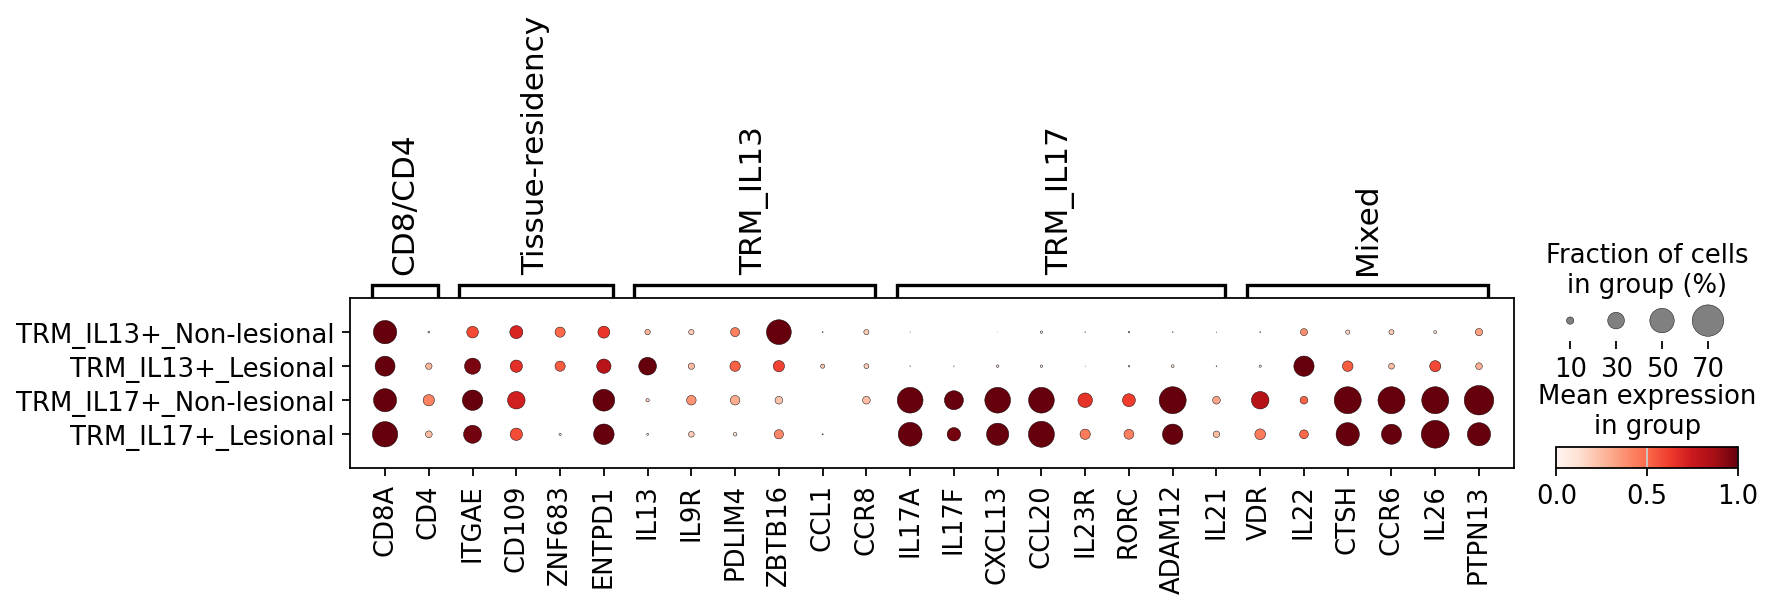

In [17]:
def remove_markers(markers, adata):
    return {
        k: [g for g in v if g in adata.var_names]
        for k, v in markers.items()
    }

# --------------------------
def add_final_with_n(adata, min_n=20):
    vc = adata.obs["lvl5_annotation"].value_counts()
    keep = vc[vc >= min_n].index

    adata.obs["final_filtered"] = (
        adata.obs["lvl5_annotation"]
        .where(adata.obs["lvl5_annotation"].isin(keep))
        .astype("category")
    )

    vc = adata.obs["final_filtered"].value_counts()

    adata.obs["final_with_n"] = (
        adata.obs["final_filtered"]
        .astype(str)
        .map(lambda x: f"{x}_n={vc[x]}" if x != "nan" else None)
        .astype("category")
    )
add_final_with_n(adata_scrna, MIN_N)
sc.pl.dotplot(
    adata_scrna,
    remove_markers(MARKERS, adata_scrna),
    groupby="Site_status2",
    dendrogram=False,
    vmax=1,
   # standard_scale="var",
    
   categories_order=ORDER,
  #               #   save=f"{POPULATION}_d_original_dotplot_scrna.pdf"

) 


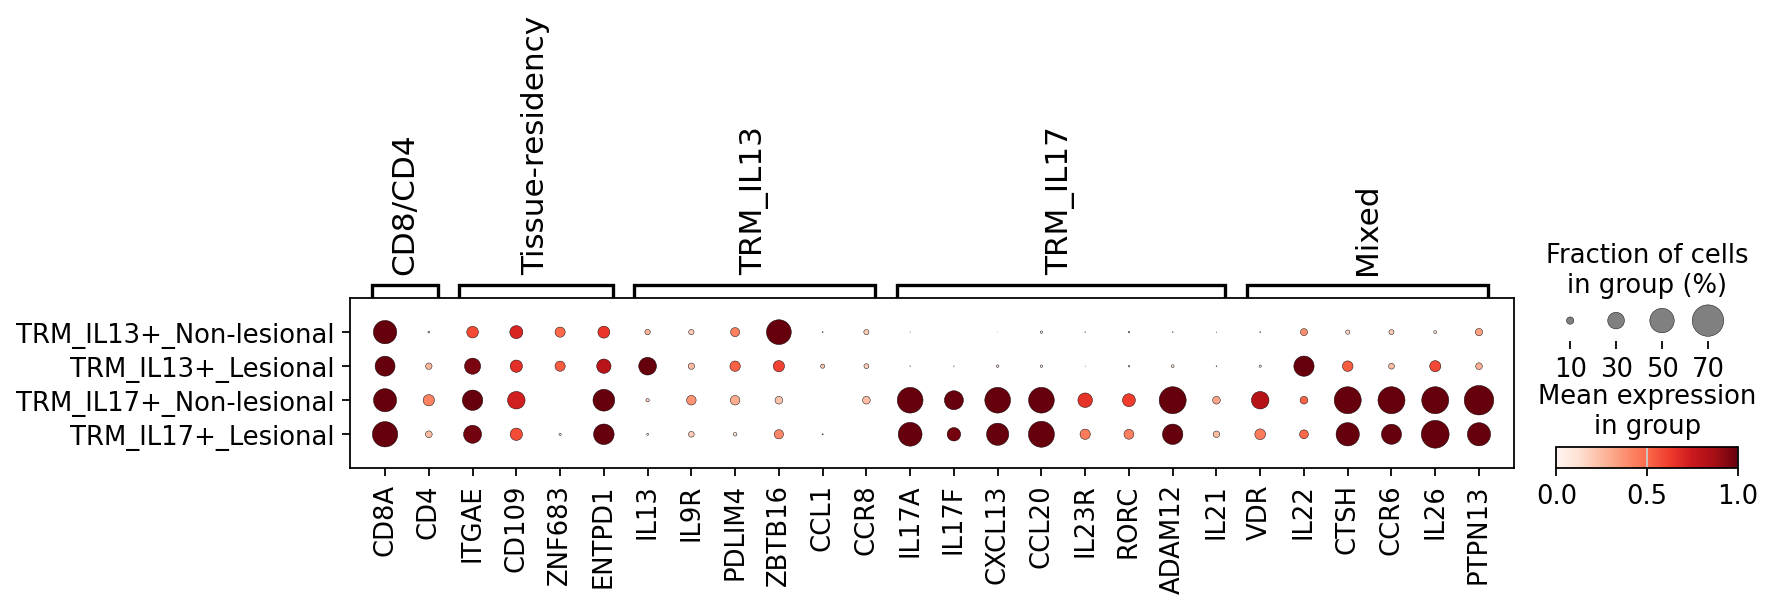

In [18]:
MIN_N = 100




add_final_with_n(adata_scrna, MIN_N)
sc.pl.dotplot(
    adata_scrna,
    remove_markers(MARKERS, adata_scrna),
    groupby="Site_status2",
    dendrogram=False,
    vmax=1,
   # standard_scale="var",
    
   categories_order=ORDER,
                  save=f"TRM_SCRNA_expression_SUPP_a.pdf"

  #               #   save=f"{POPULATION}_d_original_dotplot_scrna.pdf"

) 


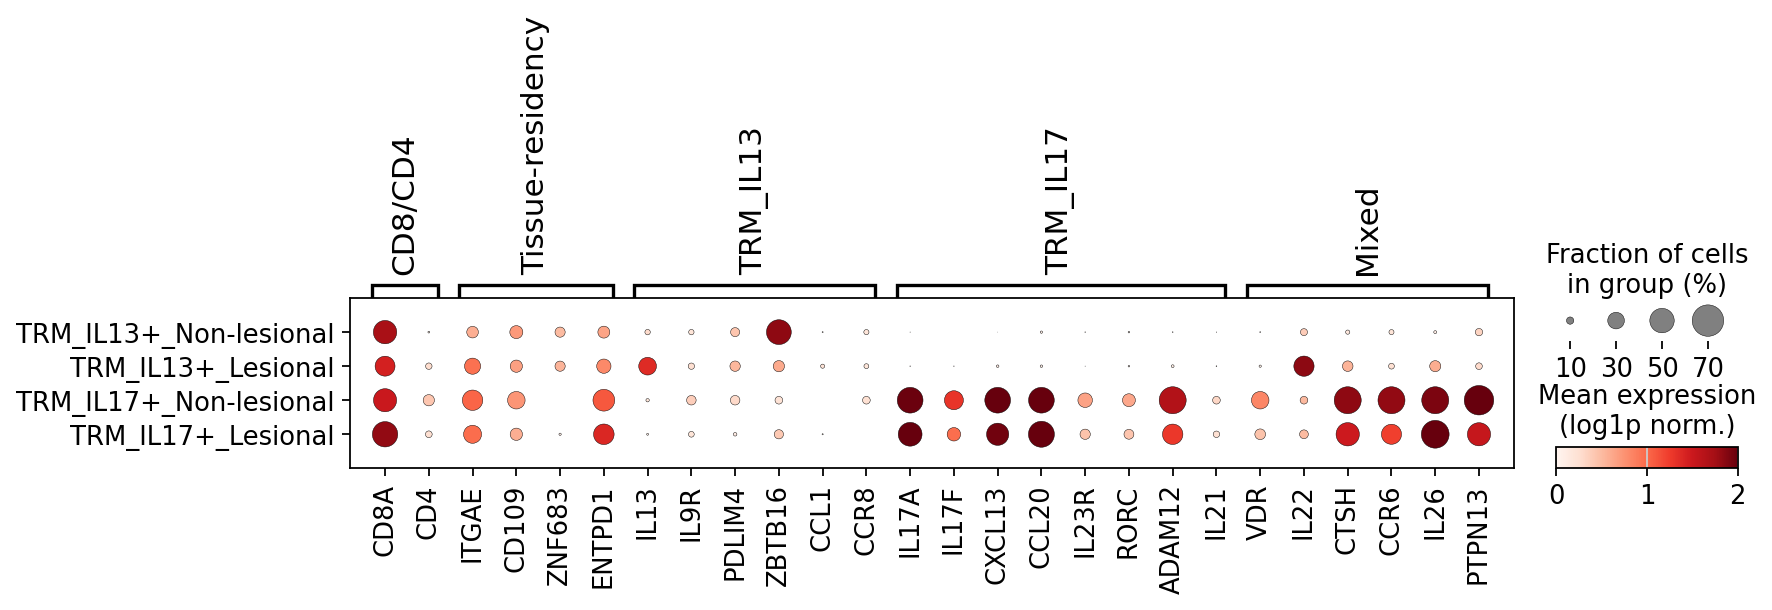

In [19]:
MIN_N = 100




add_final_with_n(adata_scrna, MIN_N)
sc.pl.dotplot(
    adata_scrna,
    remove_markers(MARKERS, adata_scrna),
    groupby="Site_status2",
    dendrogram=False,
    vmax=2,
   # standard_scale="var",
    
   categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm.)",
                  save=f"TRM_SCRNA_expression_SUPP_diffscale.pdf"

  #               #   save=f"{POPULATION}_d_original_dotplot_scrna.pdf"

) 


In [20]:
adata_scrna[adata_scrna.obs["Site_status2"]=="TRM_IL17+_Lesional"].obs.dataset_id.value_counts()

dataset_id
Ma_Psoriasis     169
Reynolds          48
Luc_Psoriasis     17
Name: count, dtype: int64

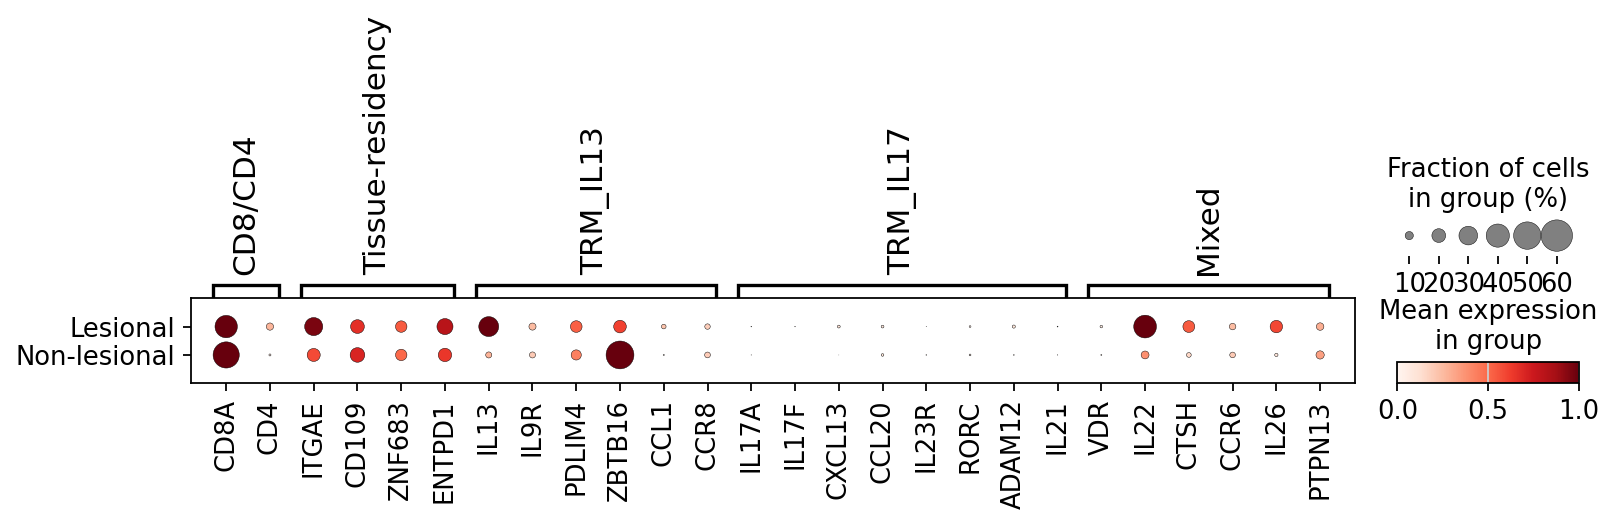

In [21]:
sc.pl.dotplot(
    adata_scrna[adata_scrna.obs["lvl5_annotation"]=="TRM_IL13+"],
    remove_markers(MARKERS, adata_scrna),
    groupby="Site_status",
    dendrogram=False,
    vmax=1,
   # standard_scale="var",
    
   #categories_order=ORDER,
  #               #   save=f"{POPULATION}_d_original_dotplot_scrna.pdf"

) 


In [22]:
# S

In [23]:
adata_5k.obs["Site_status2"]=adata_5k.obs["lvl5_annotation"].astype(str)+"_"+adata_5k.obs["Site_status"].astype(str)

In [24]:
# {x:x for x in adata_5k_2.obs.Saite_status2.unique()}

In [25]:
adata_5k_2=adata_5k[(adata_5k.obs["lvl5_annotation"]=="TRM_IL13+")|
                    (adata_5k.obs["lvl5_annotation"]=="TRM_IL17+")
                   
                   ]

In [26]:
RENAME={'TRM_IL13+_Non-lesional': 'TRM_IL13+_Non-lesional',
 'TRM_IL13+_Lesional': 'TRM_IL13+_Lesional',
 'TRM_IL13+_Week 12': 'TRM_IL13+_Week 12',
 'TRM_IL13+_Day 14_HF': 'TRM_IL13+_Day 14_HF',
 'TRM_IL13+_3D_Lesional_baseline': 'TRM_IL13+_Validation_Lesional',
 'TRM_IL13+_3D_Week12': 'TRM_IL13+_Validation_Week12',
        'TRM_IL17+_Lesional': 'TRM_IL17+_Lesional',
        'TRM_IL17+_Non-lesional': 'TRM_IL17+_Non-lesional',
       }


adata_5k_2.obs.Site_status2=adata_5k_2.obs.Site_status2.map(RENAME)
[x for x in adata_5k_2.obs.Site_status2.unique()]




['TRM_IL13+_Lesional',
 'TRM_IL13+_Week 12',
 'TRM_IL13+_Non-lesional',
 'TRM_IL13+_Day 14_HF',
 'TRM_IL17+_Non-lesional',
 'TRM_IL17+_Lesional',
 nan,
 'TRM_IL13+_Validation_Lesional',
 'TRM_IL13+_Validation_Week12']

In [27]:
ORDER=['TRM_IL13+_Non-lesional',
 'TRM_IL13+_Lesional',
 'TRM_IL13+_Week 12',
 #'TRM_IL13+_Day 14_HF',
 'TRM_IL13+_Validation_Lesional',
 'TRM_IL13+_Validation_Week12']


adata_5k_22=adata_5k_2[adata_5k_2.obs["Site_status2"].isin(ORDER)]


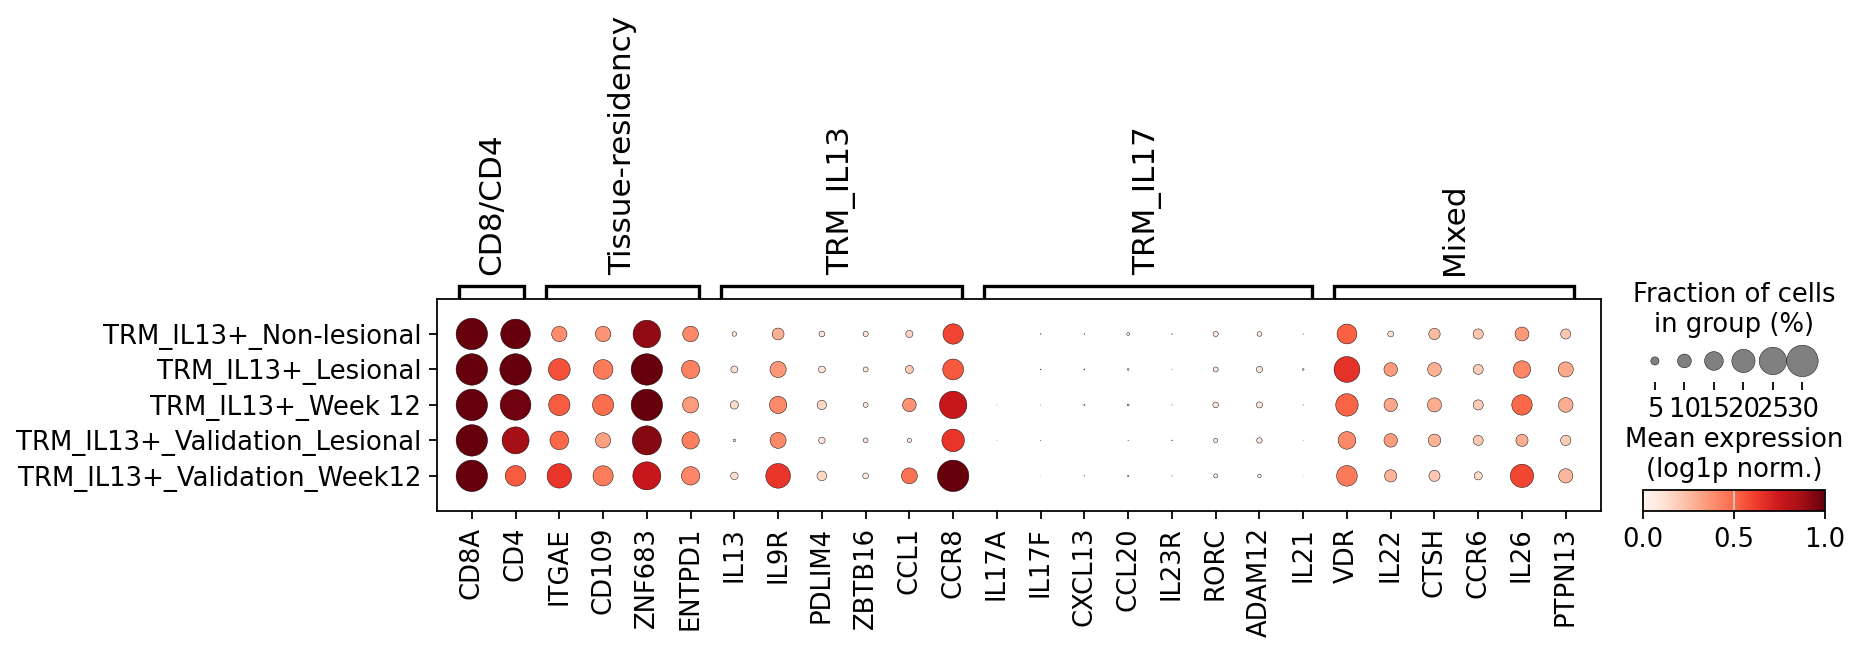

In [28]:
sc.pl.dotplot(
    adata_5k_22,
    remove_markers(MARKERS, adata_5k_22),
    groupby="Site_status2",
    dendrogram=False,
    vmax=1,
    dot_max=0.3,
   # standard_scale="var",
    
   categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm.)",
                 save=f"TRM_original_IL13.pdf"

) 


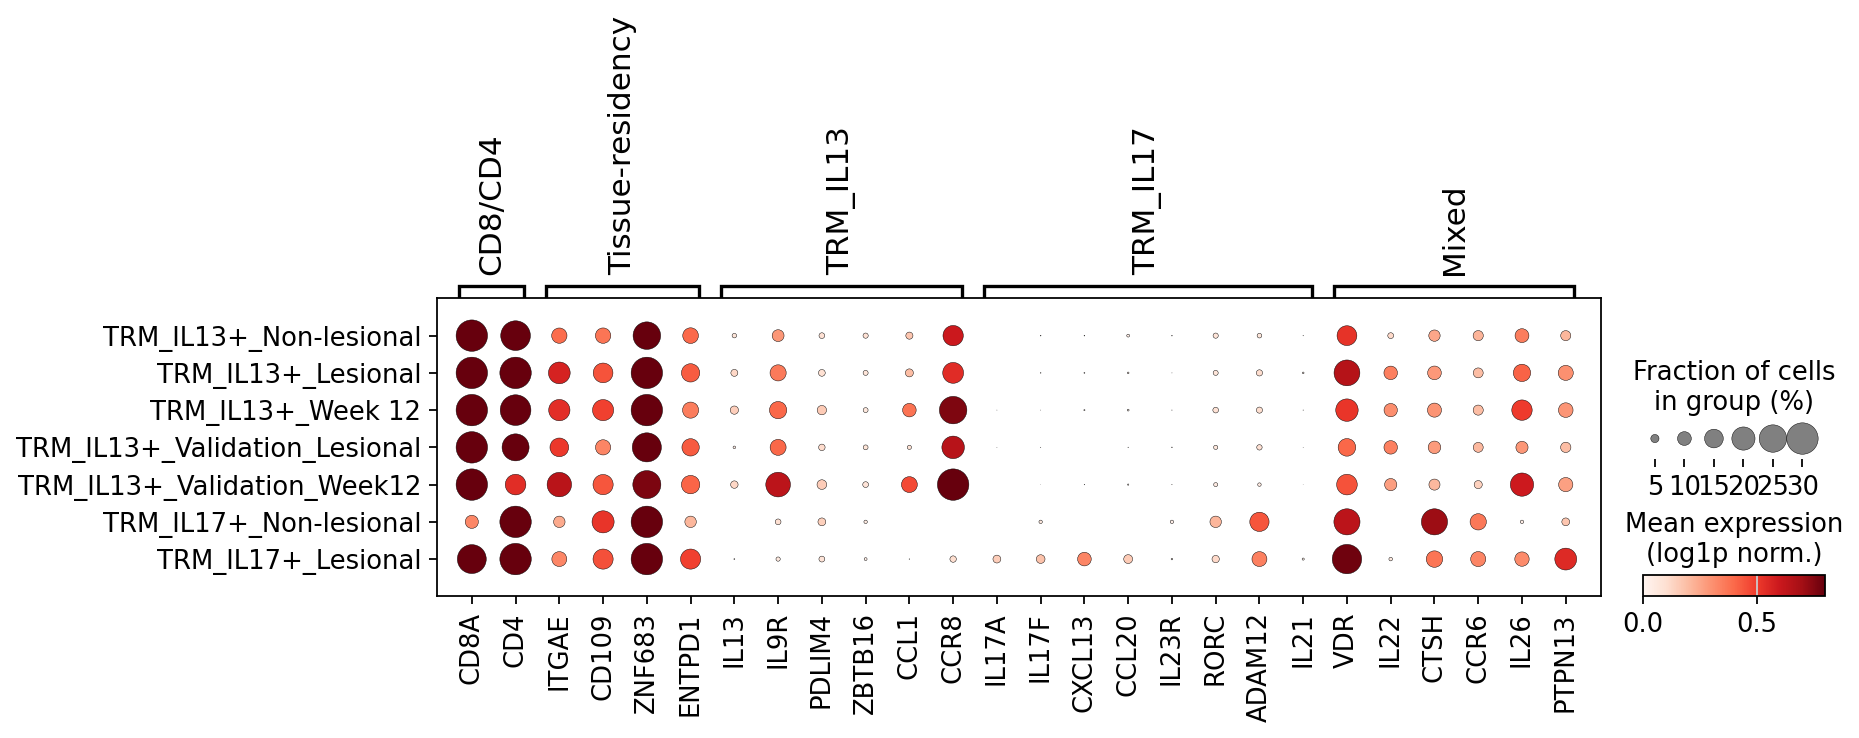

In [29]:
ORDER=[ 'TRM_IL13+_Non-lesional',
    
    'TRM_IL13+_Lesional',
 'TRM_IL13+_Week 12',
        'TRM_IL13+_Validation_Lesional',
 'TRM_IL13+_Validation_Week12',
 'TRM_IL17+_Non-lesional',
 'TRM_IL17+_Lesional',
]
sc.pl.dotplot(
    adata_5k_2[adata_5k_2.obs["Site_status2"].isin(ORDER)],
    remove_markers(MARKERS, adata_5k_2),
    groupby="Site_status2",
    dendrogram=False,
    vmax=.8,
    dot_max=0.3,
   # standard_scale="var",
    
   categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm.)",
              save=f"TRM_xenium_expression_SUPP_a.pdf"

) 


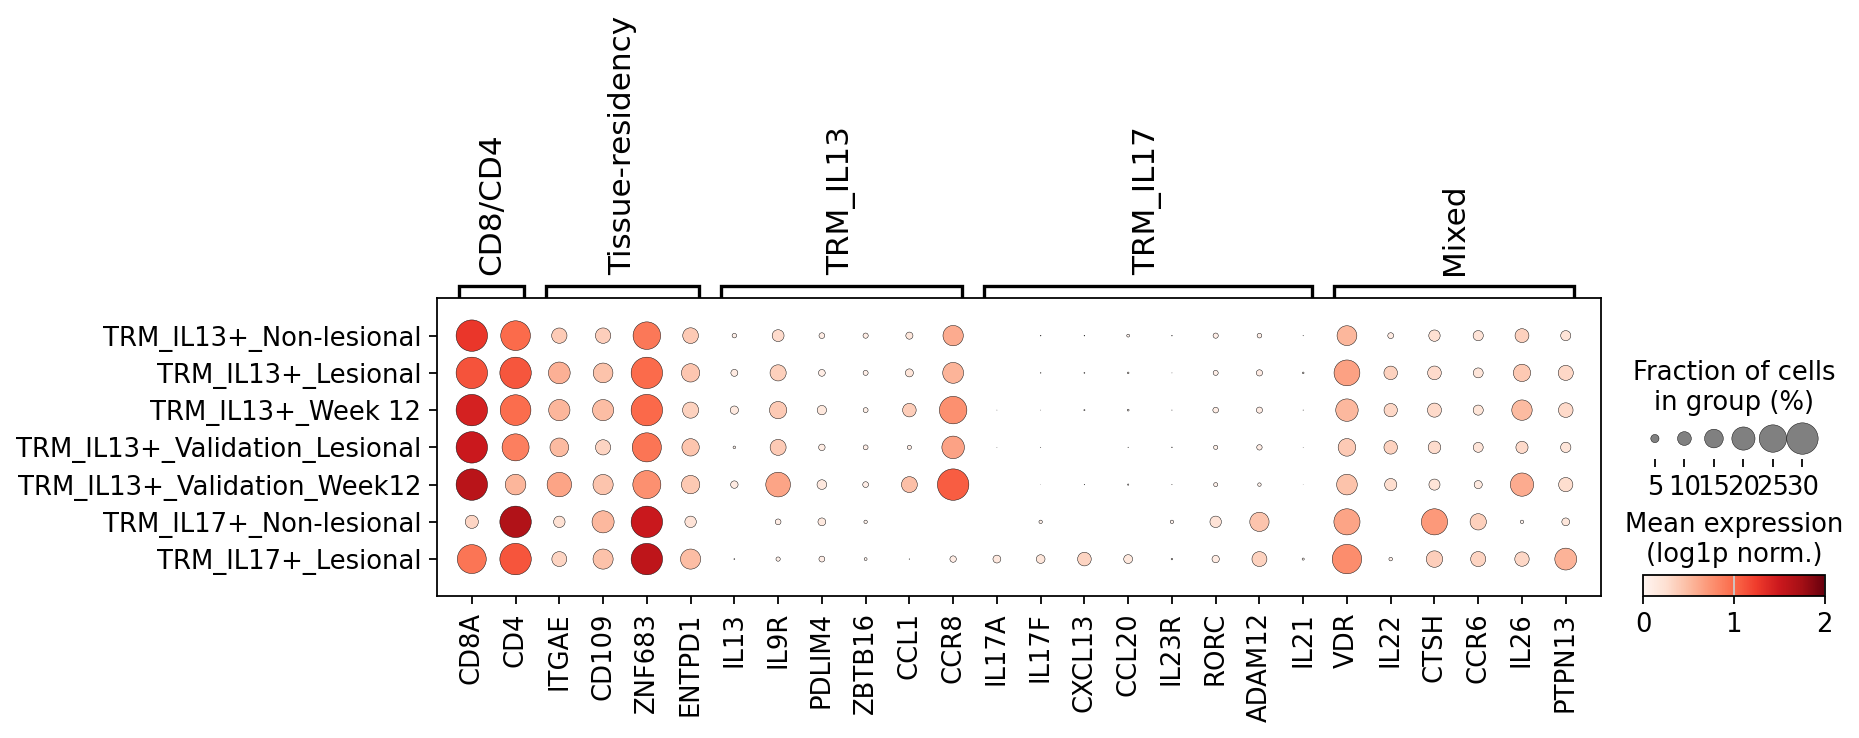

In [30]:
ORDER=[ 'TRM_IL13+_Non-lesional',
    
    'TRM_IL13+_Lesional',
 'TRM_IL13+_Week 12',
        'TRM_IL13+_Validation_Lesional',
 'TRM_IL13+_Validation_Week12',
 'TRM_IL17+_Non-lesional',
 'TRM_IL17+_Lesional',
]
sc.pl.dotplot(
    adata_5k_2[adata_5k_2.obs["Site_status2"].isin(ORDER)],
    remove_markers(MARKERS, adata_5k_2),
    groupby="Site_status2",
    dendrogram=False,
    vmax=2,
    dot_max=0.3,
   # standard_scale="var",
    
   categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm.)",
              save=f"TRM_xenium_expression_SUPP_diffscale.pdf"

) 


In [31]:
ORDER2=[#'TRM_IL13+_Non-lesional',
 'TRM_IL13+_Lesional',
 #'TRM_IL13+_Week 12',
 #'TRM_IL13+_Day 14_HF',
 'TRM_IL13+_Validation_Lesional',
 #'TRM_IL13+_Validation_Week12'
]
adata_5k_3 = adata_5k_22[adata_5k_22.obs["Site_status2"].isin(ORDER2)]
adata_5k_3.obs.niche19.value_counts()

niche19
Papillary_dermis            1994
Tzone-like                   970
Epidermis_mid                784
Small_BV                     325
Epidermis_basal              214
Sebaceous_immune             142
Epidermis_basal_cycling      120
EpidermisInflamm_mid          86
Sebaceous_duct                74
Sweat_gland_channel           46
Epidermis_APChi               34
Epidermis_upper               10
Reticular_dermis               3
EpidermisInflamm_upper         3
Sweat_gland                    3
Reticular_dermis_LE_rich       2
Hypodermis                     2
HF_outer                       2
Perineural                     1
Name: count, dtype: int64

In [32]:
counts = adata_5k_3.obs['niche19'].value_counts()
keep = counts[counts >= 100].index
adata_5k_3 = adata_5k_3[adata_5k_3.obs['niche19'].isin(keep)].copy()

In [33]:
KEEP = ['BK50_Past Lesional', 'BK49_Past Lesional wk8 relaspe', 'BK46_Never Lesional', 'BK51_Past Lesional wk8 relaspe', 'BK51_wk8 Relapse', 'BK46_Past Lesional', 'BK43_Past Lesional', 'BK43_Never Lesional', 'BK49_wk8 Relapse', 'BK49_Past Lesional', 'BK49_Never Lesional', 'BK51_Never Lesional', 'BK50_Never Lesional', 'BK51_Past Lesional']
adata_5k_3 = adata_5k_3[~adata_5k_3.obs["info_id6"].isin(KEEP)].copy()


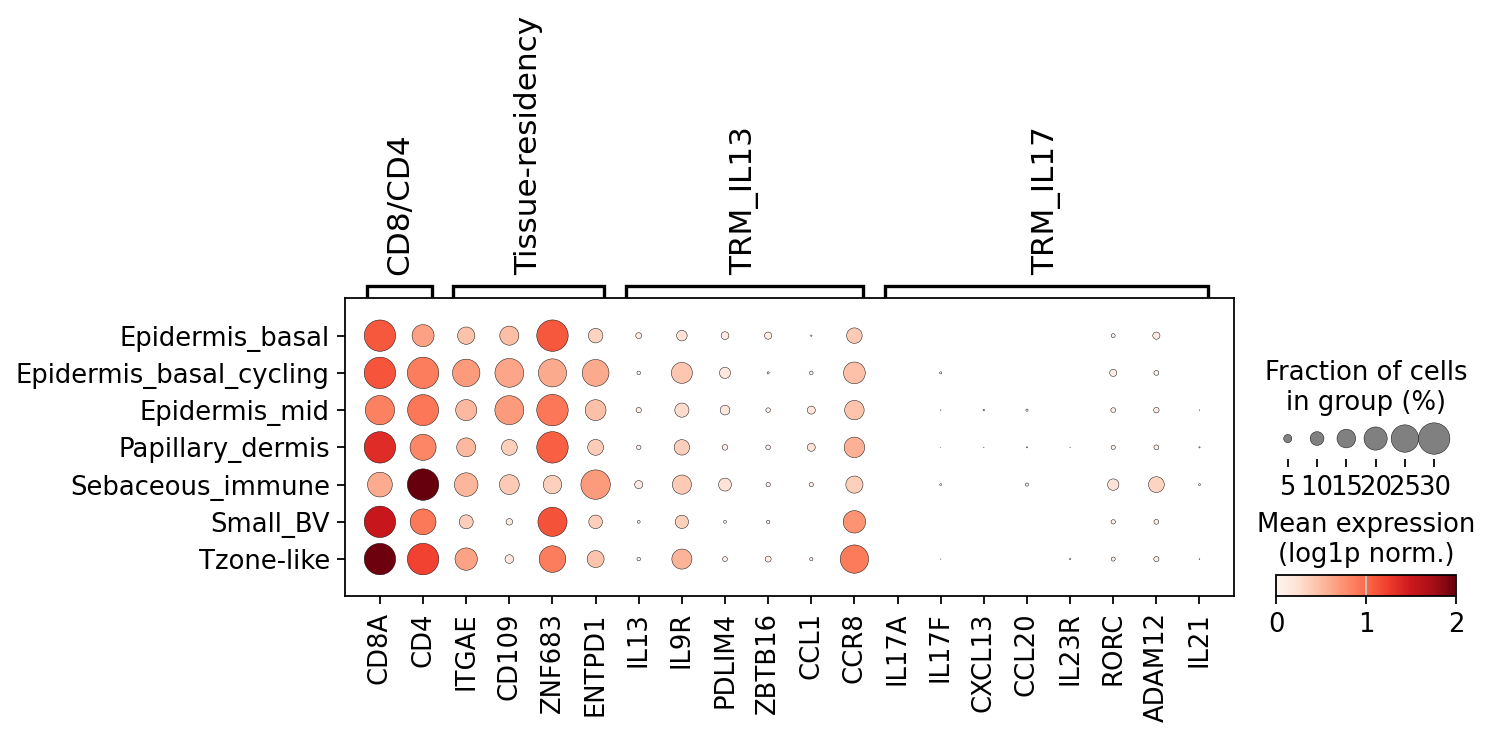

In [34]:
MARKERS = {"CD8/CD4": ['CD8A', "CD4"],
        'Tissue-residency': ['ITGAE', 'CD109', 'ZNF683', 'ENTPD1'],
 'TRM_IL13': [ 'IL13', 'NBAS',# 'CCL17',
         'AREG', 'IL9R', 'PDLIM4', 
         'ZBTB16', 'KLRC4', 'ADGRG1', 'RGS9', 'KRT7', "CCL1", "CCR8" ],
 'TRM_IL17': ['IL17A',
  'IL17F',
  'CXCL13',
  'CCL20',
  'IL23R',
  'RORC',
  'ADAM12',  'LRRN3',
  'MYO7A',
  'IL21',  ],
          }

sc.pl.dotplot(
    adata_5k_3,
    remove_markers(MARKERS, adata_5k_3),
    groupby="niche19",
    dendrogram=False,
    vmax=2,
    dot_max=0.3,
   # standard_scale="var",
    
   #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm.)",
                save=f"TRM_IL13_by_fine_niche.pdf"

) 


In [35]:
{x:x for x in sorted(adata_5k_3.obs.niche19.unique())}

{'Epidermis_basal': 'Epidermis_basal',
 'Epidermis_basal_cycling': 'Epidermis_basal_cycling',
 'Epidermis_mid': 'Epidermis_mid',
 'Papillary_dermis': 'Papillary_dermis',
 'Sebaceous_immune': 'Sebaceous_immune',
 'Small_BV': 'Small_BV',
 'Tzone-like': 'Tzone-like'}

In [36]:
RENAME = {'EpidermisInflamm_mid': 'Epidermis',
 'Epidermis_basal': 'Epidermis',
 'Epidermis_basal_cycling': 'Epidermis',
 'Epidermis_mid': 'Epidermis',
 'Papillary_dermis': 'Dermis',
 'Sebaceous_duct': 'Pilosebaceous',
 'Sebaceous_immune': 'Pilosebaceous',
 'Small_BV': 'Dermis',
 'Tzone-like': 'Dermis'}
adata_5k_3.obs["epi_dermis"]=adata_5k_3.obs.niche19.map(RENAME)

In [37]:
adata_5k_3.obs.Patient_status.value_counts()

Patient_status
3d_Lesional_baseline    2607
AD                      1942
Name: count, dtype: int64

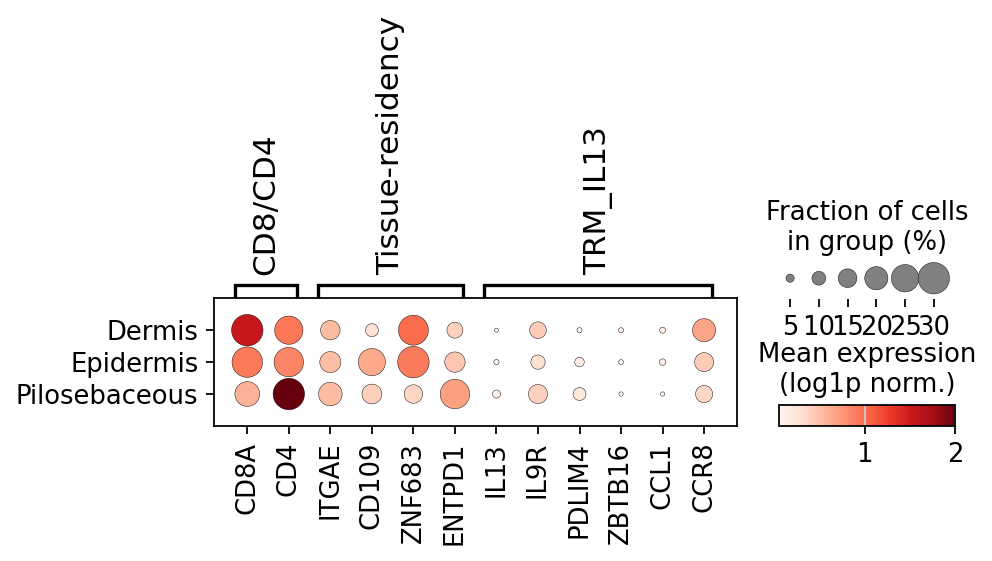

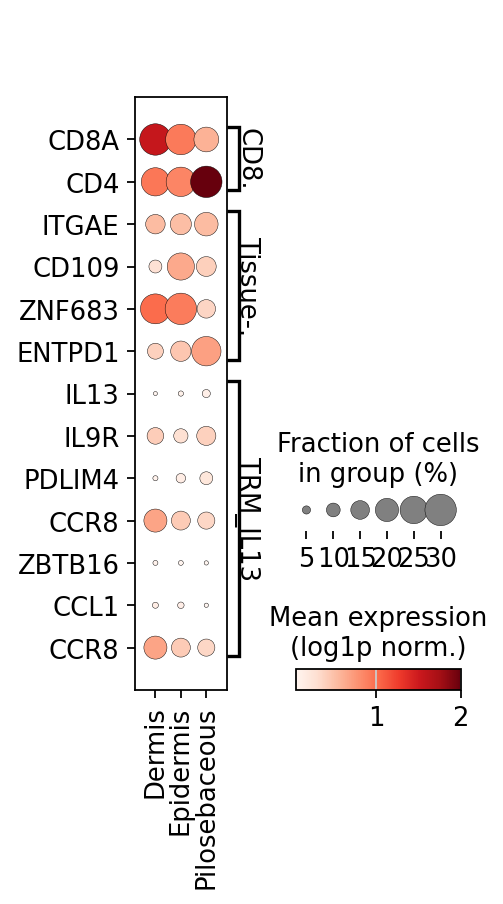

In [38]:
sc.pl.dotplot(
    adata_5k_3,
    remove_markers({'CD8/CD4': ['CD8A', 'CD4'],
 'Tissue-residency': ['ITGAE', 'CD109', 'ZNF683', 'ENTPD1'],
 'TRM_IL13': ['IL13',
  'NBAS',
  'AREG',
  'IL9R',
  'PDLIM4',
  'ZBTB16',
  'KLRC4',
  'ADGRG1',
  'RGS9',
  'KRT7',
  'CCL1',
  'CCR8']}, adata_5k_3),
    groupby="epi_dermis",
    dendrogram=False,
    vmax=2,
    dot_max=0.3,
   # standard_scale="var",
    
   #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm.)",
                  save=f"TRM_xenium_expression_SUPP_byNICHE.pdf"

              #   save=f"TRM_original_IL13.pdf"

) 


sc.pl.dotplot(
    adata_5k_3,
    remove_markers({'CD8/CD4': ['CD8A', 'CD4'],
 'Tissue-residency': ['ITGAE', 'CD109', 'ZNF683', 'ENTPD1'],
 'TRM_IL13': ['IL13',
  'NBAS',
  'AREG',
  'IL9R',
  'PDLIM4',
  'CCR8',
  'ZBTB16',
  'KLRC4',
  'ADGRG1',
  'RGS9',
  'KRT7',
  'CCL1',
  'CCR8']}, adata_5k_3),
    groupby="epi_dermis",
    dendrogram=False,
    vmax=2,
    dot_max=0.3,
    swap_axes=True,
   # standard_scale="var",
    
   #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm.)",
                  save=f"TRM_xenium_expression_SUPP_byNICHE_SWAPPEDAXIS.pdf"

              #   save=f"TRM_original_IL13.pdf"

) 


In [39]:
MARKERS

{'CD8/CD4': ['CD8A', 'CD4'],
 'Tissue-residency': ['ITGAE', 'CD109', 'ZNF683', 'ENTPD1'],
 'TRM_IL13': ['IL13',
  'NBAS',
  'AREG',
  'IL9R',
  'PDLIM4',
  'ZBTB16',
  'KLRC4',
  'ADGRG1',
  'RGS9',
  'KRT7',
  'CCL1',
  'CCR8'],
 'TRM_IL17': ['IL17A',
  'IL17F',
  'CXCL13',
  'CCL20',
  'IL23R',
  'RORC',
  'ADAM12',
  'LRRN3',
  'MYO7A',
  'IL21']}

In [40]:
ORDER2=[#'TRM_IL13+_Non-lesional',
 'TRM_IL17+_Lesional',
 #'TRM_IL13+_Week 12',
 #'TRM_IL13+_Day 14_HF',
 #'TRM_IL13+_Validation_Week12'
]

adata_5k_3 = adata_5k_2[adata_5k_2.obs["Site_status2"].isin(ORDER2)]
adata_5k_3.obs.niche19.value_counts()

niche19
EpidermisInflamm_mid      448
Papillary_dermis           98
Sebaceous_immune           71
Epidermis_basal            59
Tzone-like                 16
Sebaceous_duct             15
EpidermisInflamm_upper      5
Epidermis_mid               2
Epidermis_upper             2
HF_outer                    1
Sebaceous_gland             1
Small_BV                    1
Name: count, dtype: int64

In [41]:
counts = adata_5k_3.obs['niche19'].value_counts()
keep = counts[counts >= 50].index
adata_5k_3 = adata_5k_3[adata_5k_3.obs['niche19'].isin(keep)].copy()

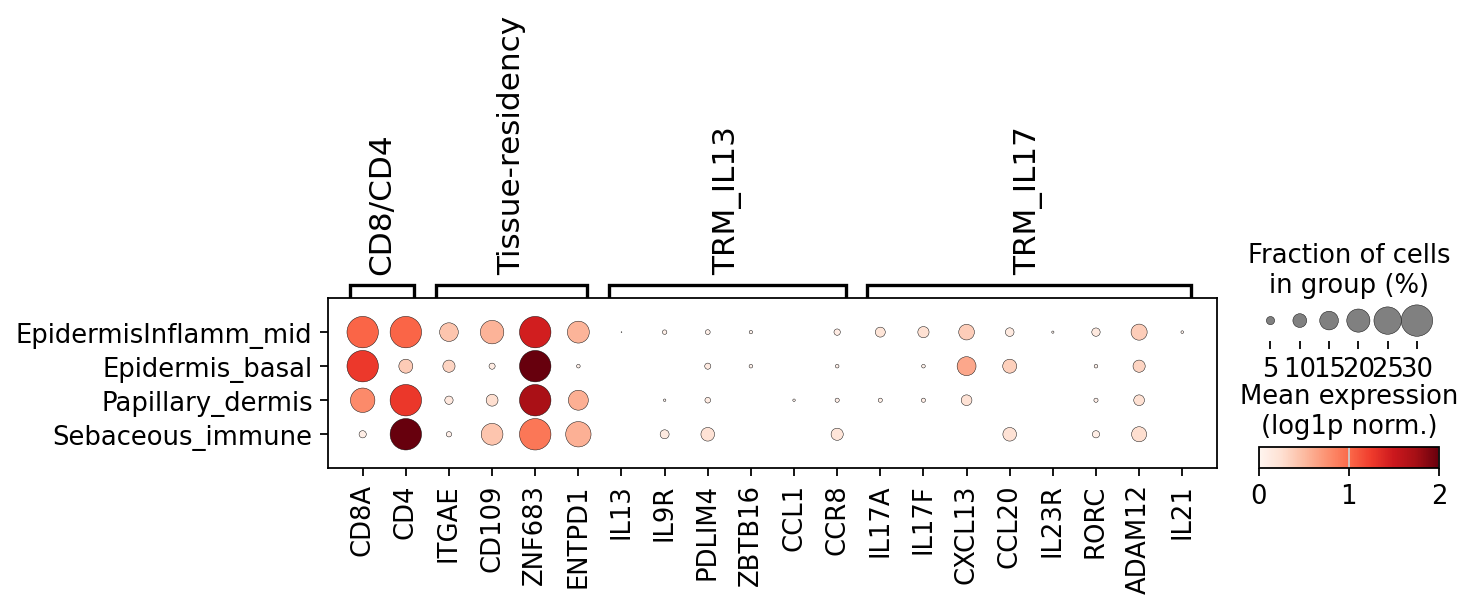

In [42]:
MARKERS = {"CD8/CD4": ['CD8A', "CD4"],
        'Tissue-residency': ['ITGAE', 'CD109', 'ZNF683', 'ENTPD1'],
 'TRM_IL13': [ 'IL13', 'NBAS',# 'CCL17',
         'AREG', 'IL9R', 'PDLIM4', 
         'ZBTB16', 'KLRC4', 'ADGRG1', 'RGS9', 'KRT7', "CCL1", "CCR8" ],
 'TRM_IL17': ['IL17A',
  'IL17F',
  'CXCL13',
  'CCL20',
  'IL23R',
  'RORC',
  'ADAM12',  'LRRN3',
  'MYO7A',
  'IL21',  ],
          }

sc.pl.dotplot(
    adata_5k_3,
    remove_markers(MARKERS, adata_5k_3),
    groupby="niche19",
    dendrogram=False,
    vmax=2,
    dot_max=0.3,
   # standard_scale="var",
    
   #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm.)",
                save=f"TRM_IL17_by_fine_niche.pdf"

) 


In [43]:
stop

NameError: name 'stop' is not defined

In [ ]:
import pandas as pd
sc.tl.rank_genes_groups(adata_5k_3, "niche19", method='t-test', key_added="de_leiden");
df2 = pd.DataFrame(adata_5k_3.uns['de_leiden']['names'])


In [ ]:
# adata_ilc_x = adata[(adata.obs[CATEGORY].str.startswith("TRM"))|
#                     (adata.obs[CATEGORY].str.startswith("ILC"))|
#                     (adata.obs[CATEGORY].str.startswith("cDC"))
#                    ]   .copy()
# vc = adata_ilc_x.obs[CATEGORY].value_counts()

# keep = vc[vc >= 2].index

# adata_ilc_x = adata_ilc_x[adata_ilc_x.obs[CATEGORY].isin(keep)].copy()


select_population = list(df2.columns)[-3]  # JAW
print(select_population)

genes0 = df2[select_population][:50]

genes1 = df2[select_population][50:100]
genes2 = df2[select_population][100:150]
genes3 = df2[select_population][150:200]
genes4 = df2[select_population][200:250]
genes5 = df2[select_population][250:300]
genes6 = df2[select_population][300:350]

CATEGORY="niche19"

sc.pl.dotplot(
    adata_5k_3,
    genes0,
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False, 
    dot_max=.3,
)
sc.pl.dotplot(
  adata_5k_3,
    genes1,
    groupby=CATEGORY,
 standard_scale="var",
    dendrogram=False, 
        dot_max=0.3,

) 




In [ ]:
import pandas as pd
sc.tl.rank_genes_groups(adata_5k_2, "Site_status2", method='t-test', key_added="de_leiden");
df2 = pd.DataFrame(adata_5k_2.uns['de_leiden']['names'])


In [ ]:
# adata_ilc_x = adata[(adata.obs[CATEGORY].str.startswith("TRM"))|
#                     (adata.obs[CATEGORY].str.startswith("ILC"))|
#                     (adata.obs[CATEGORY].str.startswith("cDC"))
#                    ]   .copy()
# vc = adata_ilc_x.obs[CATEGORY].value_counts()

# keep = vc[vc >= 2].index

# adata_ilc_x = adata_ilc_x[adata_ilc_x.obs[CATEGORY].isin(keep)].copy()


select_population = list(df2.columns)[4]  # JAW
print(select_population)

genes0 = df2[select_population][:50]

genes1 = df2[select_population][50:100]
genes2 = df2[select_population][100:150]
genes3 = df2[select_population][150:200]
genes4 = df2[select_population][200:250]
genes5 = df2[select_population][250:300]
genes6 = df2[select_population][300:350]

CATEGORY="Site_status2"

sc.pl.dotplot(
    adata_5k_2,
    genes0,
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False, 
    dot_max=.3,
)
sc.pl.dotplot(
  adata_5k_2,
    genes1,
    groupby=CATEGORY,
 standard_scale="var",
    dendrogram=False, 
        dot_max=0.3,

) 




In [ ]:
CXCL9, CXCL20, 

In [ ]:
sc.pl.dotplot(
    adata_5k_2,
    genes2,
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False, 
    dot_max=.3,
)
sc.pl.dotplot(
  adata_5k_2,
    genes3,
    groupby=CATEGORY,
 standard_scale="var",
    dendrogram=False, 
        dot_max=0.3,

) 




# Recode T cells

In [ ]:
RENAME = {'T': 'T',
 'Treg': 'T_other',
 'TRM_IL13+': 'TRM_IL13+',
 'Th': 'T_other',
 'T_γδ': 'T_other',
 'Tnaive': 'T_other',
 'Tc': 'T_other',
 'Treg_LRRC32+': 'T_other',
 'T_Prolif': 'T_other',
 'Th_PPARGhi': 'T_other',
 'TRM_IL17+': 'TRM_IL17+',
         'Tc1':   'T_other',
'Tc0': 'T_other',
'Tc3_IFNGhi': 'T_other',
'Tc2': 'T_other',
'Treg/Tnaive_prolif': 'T_other',
'TR1': 'T_other',
'Th/TRM prolif':  'T_other',
'Tc_Prolif': 'T_other',
          "TRM_prolif":  "TRM_prolif",
         }
adata_5k.obs["tcells2"] =  adata_5k.obs["lvl5_annotation"].map(RENAME).fillna("Other")


In [ ]:
i=0
for x in [x for x in adata_5k.obs["lvl5_annotation"].unique() if x.startswith("T")]:
    if x not in RENAME.keys():
        print(x)

In [ ]:
# file_path = "/nfs/team298/ls34/color_for_adult_skin2.pkl"

# with open(file_path, "rb") as fh:
#     colors = pickle.load(fh)


# colors = colors | {        'T_other':'#F4D1A1',
#                    "T": '#F4D1A1', #'#8C6A3B',
                  
#                   }



In [ ]:
# MIN_CELLS = 20
# adata_5k_i=adata_5k

# trm_counts = adata_5k_i.obs.loc[
#     adata_5k_i.obs["lvl5_annotation"] == "TRM_IL13+",
#     "info_id6"
# ].value_counts()
# MIN_CELLS = 20

# trm_counts = adata_5k_i.obs.loc[
#     adata_5k_i.obs["lvl5_annotation"] == "TRM_IL13+",
#     "info_id6"
# ].value_counts()

# samples_to_keep = trm_counts[trm_counts > MIN_CELLS].index
# samples_to_keep

# TRM+ILC plots

In [ ]:
adata_5k.obs["Site_status"].value_counts()

In [ ]:
RENAME = {'T': 'T_other',
 'Treg': 'Treg',
 'TRM_IL13+': 'TRM_IL13+',
 'Th': 'T_other',
 'T_γδ': 'T_other',
 'Tnaive': 'T_other',
 'Tc': 'T_other',
 'Treg_LRRC32+': 'Treg_LRRC32+',
 'T_Prolif': 'T_other',
 'Th_PPARGhi': 'T_other',
 'TRM_IL17+': 'TRM_IL17+',
         'Tc1':   'T_other',
'Tc0': 'T_other',
'Tc3_IFNGhi': 'T_other',
'Tc2': 'T_other',
'Treg/Tnaive_prolif': 'T_other',
'TR1': 'T_other',
'Th/TRM prolif':  'T_other',
#'TransitionalDC'
'Tc_Prolif': 'T_other',
          "TRM_prolif":  "TRM_prolif",
          'ILC3': 'ILC3',
 'ILC2': 'ILC2',
 'ILC3_CCL1+PTGDS+': 'ILC3_CCL1+PTGDS+',
 'ILC1': 'ILC1',
 'ILC1_NCR2+P2RX7+': 'ILC1_NCR2+P2RX7+',
 'ILC_Prolif': 'ILC_Prolif'
         
         }
adata_5k.obs["tcells2"] =  adata_5k.obs["lvl5_annotation"].map(RENAME).fillna("Other")


In [ ]:
SAMPLE = '3D_Week12'
adata_5k_i = adata_5k[adata_5k.obs["Site_status"]==SAMPLE].copy()


In [ ]:
file_path = "/nfs/team298/ls34/color_for_adult_skin2.pkl"

with open(file_path, "rb") as fh:
    colors = pickle.load(fh)


colors = colors | {        'T_other':'#F4D1A1',
                   "T": '#F4D1A1', #'#8C6A3B',
                  
                  }



In [ ]:
desired_order = [
    'TRM_IL13+',
    'ILC3_CCL1+PTGDS+',
    'ILC3',
    'ILC1',
    'ILC2',
    'T_other',
    'Treg',
    'Treg_LRRC32+',
    'Other',
]


In [ ]:
adata_5k_i.obs.info_id6.value_counts()

In [ ]:
adata_5k_i.obs.sample_id.value_counts()

In [ ]:

sc.settings.set_figure_params(dpi=300,dpi_save=300 , facecolor="white", frameon=False, figsize=(30,30))

for SAMPLE in ["3D_BK25_week12-C1"]:
    print(SAMPLE)
    adata_i = adata_5k[adata_5k.obs["sample_id"] == SAMPLE]
    #adata_i=adata_i[adata_i.obs["niche19"].str.startswith("Epi")]
    
    adata_i.obs["tcells2"] = pd.Categorical(
        adata_i.obs["tcells2"],
        categories=desired_order,
        ordered=True
    )

    
    adata_i.obs["tcells2"] = adata_i.obs["tcells2"].astype("category")
    adata_i.uns['tcells2_colors'] = [
        colors.get(cat, '#D3D3D3') for cat in adata_i.obs['tcells2'].cat.categories
    ]

    

    sc.pl.spatial(
        adata_i,
        #library_id="spatial",
        #shape=None,
        color="tcells2",
        spot_size=10,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.3,
        legend_fontsize=6,
        #show=True
     # save=f"1g_trm_il13_{SAMPLE}+WEEK12_smaller.pdf"

    )
#     sc.pl.spatial(
#         adata_i,
#         #library_id="spatial",
#         #shape=None,
#         color="tcells2",
#         spot_size=10,
#         vmax=1,
#         #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
#         edgecolor="black",
#         linewidth=0.2,
#         legend_fontsize=6,
#         #show=True
#        save=f"1g_trm_il13_{SAMPLE}+WEEK12_smallest.pdf"
# #
#     )
 
 

In [ ]:
import pickle

inpath ="/nfs/team298/ls34/dicts/skin_labels14.pkl"
# "/nfs/team298/ls34/skin_final10.pkl"

with open(inpath, "rb") as f:
    md = pickle.load(f)
adata_5k.obs["tmp"] = adata_5k.obs_names.map(md)
adata_5k.obs["Annotation"]=adata_5k.obs["tmp"].fillna(adata_5k.obs["lvl5_annotation"])
#adata.obs["tmp"].value_counts()

In [ ]:
{x:x for x in adata_5k.obs["Annotation"].unique() if x.startswith("T")}

In [ ]:
RENAME = {'T': 'T',
 'Treg': 'T_other',
 'TRM_IL13+': 'TRM_IL13+',
 'Th': 'T_other',
 'T_γδ': 'T_other',
 'Tnaive': 'T_other',
 'Tc': 'T_other',
 'Treg_LRRC32+': 'T_other',
 'T_Prolif': 'T_other',
 'Th_PPARGhi': 'T_other',
 'TRM_IL17+': 'TRM_IL17+',
         'Tc1':   'T_other',
'Tc0': 'T_other',
'Tc3_IFNGhi': 'T_other',
'Tc2': 'T_other',
'Treg/Tnaive_prolif': 'T_other',
'TR1': 'T_other',
'Th/TRM prolif':  'T_other',
'Tc_Prolif': 'T_other',
          "TRM_prolif":  "TRM_prolif",
         }
adata_5k.obs["tcells3"] =  adata_5k.obs["Annotation"].map(RENAME).fillna("Other")
adata_5k.obs["tcells3"].value_counts()

In [ ]:

sc.settings.set_figure_params(dpi=300,dpi_save=300 , facecolor="white", frameon=False, figsize=(30,30))

for SAMPLE in ["3D_BK25_week12-C1"]:
    print(SAMPLE)
    adata_i = adata_5k[adata_5k.obs["sample_id"] == SAMPLE]
    #adata_i=adata_i[adata_i.obs["niche19"].str.startswith("Epi")]
    
    adata_i.obs["tcells3"] = pd.Categorical(
        adata_i.obs["tcells3"],
        categories=desired_order,
        ordered=True
    )

    
    adata_i.obs["tcells3"] = adata_i.obs["tcells3"].astype("category")
    adata_i.uns['tcells3_colors'] = [
        colors.get(cat, '#D3D3D3') for cat in adata_i.obs['tcells3'].cat.categories
    ]

    

    sc.pl.spatial(
        adata_i,
        #library_id="spatial",
        #shape=None,
        color="tcells3",
        spot_size=10,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.3,
        legend_fontsize=6,
        #show=True
     save=f"NEW_TRMWEEK12_{SAMPLE}+_smaller.pdf"

    )
 

In [ ]:
sc.settings.set_figure_params(dpi=300,dpi_save=300 , facecolor="white", frameon=False, figsize=(30,30))

for SAMPLE in ["BK25-SKI-27-FO-5"]:
    print(SAMPLE)
    adata_i = adata_5k[adata_5k.obs["Sample ID"] == SAMPLE]
    #adata_i=adata_i[adata_i.obs["niche19"].str.startswith("Epi")]
    
    adata_i.obs["tcells2"] = pd.Categorical(
        adata_i.obs["tcells2"],
        categories=desired_order,
        ordered=True
    )

    
    adata_i.obs["tcells2"] = adata_i.obs["tcells2"].astype("category")
    adata_i.uns['tcells2_colors'] = [
        colors.get(cat, '#D3D3D3') for cat in adata_i.obs['tcells2'].cat.categories
    ]

    

    sc.pl.spatial(
        adata_i,
        #library_id="spatial",
        #shape=None,
        color="tcells2",
        spot_size=10,
        vmax=1,
        #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
        edgecolor="black",
        linewidth=0.3,
        legend_fontsize=6,
        #show=True
      save=f"1g_trm_il13_{SAMPLE}+WEEK12_smaller.pdf"

    )
#     sc.pl.spatial(
#         adata_i,
#         #library_id="spatial",
#         #shape=None,
#         color="tcells2",
#         spot_size=10,
#         vmax=1,
#         #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
#         edgecolor="black",
#         linewidth=0.2,
#         legend_fontsize=6,
#         #show=True
#        save=f"1g_trm_il13_{SAMPLE}+WEEK12_smallest.pdf"
# #
#     )
 
 

In [ ]:
adata_i.obs["group"]=adata_i.obs["lvl5_annotation"]

In [ ]:
df = adata_i.obs

In [ ]:
# how can i make a new df just with the cols df["cell_id"] and df["group"]?
df = df[["cell_id", "group"]].copy()

In [ ]:
df.to_csv('xenium_bk25.csv')

In [ ]:
1

In [ ]:
adata_i.obs.sample_id.value_counts()

In [ ]:
sc.settings.set_figure_params(
    dpi=300,
    dpi_save=300,
    facecolor="white",
    frameon=False,
    figsize=(30, 30)
)

desired_order = [
    'TRM_IL13+',
    'ILC3_CCL1+PTGDS+',
    'ILC3',
    'ILC1',
    'ILC2',
    'T_other',
    'Treg',
    'Treg_LRRC32+',
    'Other',
]

for SAMPLE in ["BK25-SKI-27-FO-5"]:
    print(SAMPLE)
    adata_i = adata_5k[adata_5k.obs["Sample ID"] == SAMPLE]

    # enforce category order
    adata_i.obs["tcells2"] = pd.Categorical(
        adata_i.obs["tcells2"],
        categories=desired_order,
        ordered=True
    )

    adata_i.uns['tcells2_colors'] = [
        colors.get(cat, '#D3D3D3')
        for cat in adata_i.obs['tcells2'].cat.categories
    ]

    # plot without saving, so we can tweak legend
    ax_list = sc.pl.spatial(
        adata_i,
        color="tcells2",
        spot_size=10,
        vmax=1,
        edgecolor="black",
        linewidth=0.3,
        legend_fontsize=6,
        show=False
    )

    # sc.pl.spatial returns a list of Axes
    ax = ax_list[0]

    # rebuild legend in 4 columns
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles, labels,
        ncol=5,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=16,
        frameon=False
    )
    plt.show()
   # plt.savefig(f"1g_trm_il13_{SAMPLE}+WEEK12_smaller.pdf", dpi=300, bbox_inches="tight")
    plt.close()

In [ ]:
STOP

# trm il17+

In [ ]:
trm_counts = adata_5k.obs.loc[
    adata_5k.obs["lvl5_annotation"] == "TRM_IL17+",
    "info_id6"
].value_counts()
trm_counts.head(20)

In [ ]:
adata_5k[adata_5k.obs["info_id6"].str.startswith("Lesional_CE4")].obs.info_id6.value_counts()

In [ ]:
adata_5k_ii=adata_5k[adata_5k.obs["info_id6"]=="Lesional_CE4-SKI-27-FO-4-S22_replicate"]
adata_5k_ii=adata_5k_ii[adata_5k_ii.obs["niche17"].str.startswith("Epidermis")]
adata_5k_ii.shape

In [ ]:

sc.settings.set_figure_params(
    dpi=300,
    dpi_save=300,
    facecolor="white",
    frameon=False,
    figsize=(30, 30)
)



for SAMPLE in ["Lesional_CE4-SKI-27-FO-4-S22-A2"]:
    print(SAMPLE)
    adata_i = adata_5k[adata_5k.obs["info_id6"] == SAMPLE]

    # enforce category order
    adata_i.obs["tcells2"] = pd.Categorical(
        adata_i.obs["tcells2"],
       # categories=desired_order,
        ordered=True
    )

    adata_i.uns['tcells2_colors'] = [
        colors.get(cat, '#D3D3D3')
        for cat in adata_i.obs['tcells2'].cat.categories
    ]

#     # plot without saving, so we can tweak legend
    sc.pl.spatial(
        adata_i,
        color="tcells2",
        spot_size=10,
        vmax=1,
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,
            show=True,
        groups=["TRM_IL17+"],
        save="trm_ce4.pdf"
        
    )
    sc.pl.spatial(
        adata_i,
        color="tcells3",
        spot_size=10,
        vmax=1,
        edgecolor="black",
        linewidth=0.1,
        legend_fontsize=6,
        show=False,
        groups=["TRM_IL17+"]
    )


#     # sc.pl.spatial returns a list of Axes
#     ax = ax_list[0]

#     # rebuild legend in 4 columns
#     handles, labels = ax.get_legend_handles_labels()
#     ax.legend(
#         handles, labels,
#         ncol=5,
#         bbox_to_anchor=(1.05, 1),
#         loc="upper left",
#         fontsize=16,
#         frameon=False
#     )
#     plt.show()
#    # plt.savefig(f"1g_trm_il13_{SAMPLE}+WEEK12_smaller.pdf", dpi=300, bbox_inches="tight")
#     plt.close()

In [ ]:
adata_5k

In [ ]:
sc.settings.set_figure_params(
    dpi=300,
    dpi_save=300,
    facecolor="white",
    frameon=False,
    figsize=(30, 30)
)



for SAMPLE in ["Lesional_CE4-SKI-27-FO-4-S22-A2"]:
    print(SAMPLE)
    adata_i = adata_5k[adata_5k.obs["info_id6"] == SAMPLE]

    # enforce category order
    adata_i.obs["tcells2"] = pd.Categorical(
        adata_i.obs["tcells2"],
       # categories=desired_order,
        ordered=True
    )

    adata_i.uns['tcells2_colors'] = [
        colors.get(cat, '#D3D3D3')
        for cat in adata_i.obs['tcells2'].cat.categories
    ]

    # plot without saving, so we can tweak legend
    ax_list = sc.pl.spatial(
        adata_i,
        color="tcells2",
        spot_size=10,
        vmax=1,
        edgecolor="black",
        linewidth=0.3,
        legend_fontsize=6,
        show=False
    )

    # sc.pl.spatial returns a list of Axes
    ax = ax_list[0]

    # rebuild legend in 4 columns
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles, labels,
        ncol=5,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=16,
        frameon=False
    )
    plt.show()
   # plt.savefig(f"1g_trm_il13_{SAMPLE}+WEEK12_smaller.pdf", dpi=300, bbox_inches="tight")
    plt.close()

In [ ]:
# ALL_T = {'Conventional': ['CD3D', "CD4", "CD8A"],
#  'Treg': ['FOXP3', 'TIGIT', 'CTLA4', 'IL2RA'],
#  'Activated_Treg': ['LRRC32',
#   'IL1R1',
#   'IL1R2',
#  # 'CMSS1',
#   'LAYN',
#   'CCR8',
#   'NR4A1'],
#  'TR1': ['EOMES',
#   'IL10',
#   'LAG3',
#   'HAVCR2',
#   'PDCD1',
#   'FOXB1',
#   'TNFSF9',
#   'VCAM1'],
#           'Cycling': ['UBE2C', 'MKI67', 'TOP2A'],
#  'Naive/Tcm': ['SELL', 'CCR7', 'S1PR1', 'TCF7', 'PAK2', 'ICAM2', 'PASK', ],
#  'GIMAPs': ['GIMAP1', 'GIMAP4', 'GIMAP5', 'GIMAP7'],
#  'Th': ['CD4', 'CD40LG', 'MCAM', ],
#          "CCR6+": ['CCR6', 'BACH2', "CXCR6"],
#  'Th_PPARGhi': ['PPARG', 'BTD', 'KIF13B', 'DGKH', 'RORA-AS1','SPAG1'],
#  'Th6': ['BACH2', 'XYLT1', 'GNAQ', 'PPARG',  'ZEB2', # 'PTGS2', 'MMP7',
#         "ZHX2"],
#          "CD8": ["CD8A"],
#           'TC_IL9R': ['GPR15', 'CD8B2', 'IL9R', 'DONSON',
#                      "AGAP1", "C12orf42", "GML", "CCR5",
#                      ],

                
#  'CD8A+ cytotoxic T cells': ["KLRG1", 'GZMK', 'CCL4', 'IFNG', 'TNFSF9', 'CCL3'],
         
#  'Cytotoxic': ['NKG7', 'CCL5', 'GZMA'],
#  'Tissue-residency\n markers': ['CD8A', 'ITGAE', 'CD109', 'ZNF683', 'ENTPD1'],
#  'T_2': ['IL22', 'IL13', 'NBAS',# 'CCL17',
#          'AREG', 'IL9R', 'PDLIM4', 'CCR8'],
#  'TRM_IL13': ['ZBTB16', 'KLRC4', 'ADGRG1', 'RGS9'],
#  'T_17': ['IL17A',
#   'IL17F',
#   'CXCL13',
#   'CCL20',
#   'IL23R',
#   'RORC',
#   'ADAM12',
#   'LRRN3',
#   'MYO7A',
#   'IL21',
#   'CTSH',
#   'VDR',
#   'CCR6',
#   'IL26'],
#  'Other': ['PTPN13', #'ITGA1'
#           ],
#  'ITGA1hi': ['ITGA1', 'ZHX2', 'BICD1', 'PRR5L', 'ST8SIA1', 'ZNF407', "KLRG1"],
#  'Memory': ['CD69'],
#  'Gamma-delta': ['FXYD2',
#   'TRGC2',
#   'TRDV1',
#   'TRGV4',
#   'EMP1',
#   'NSG1',
#   'MPZL2',
#   'XCL1',
#   'KLRC2',
#   'KLRC3',
#   'KLRD1',
#   'TRDC',
#   'VSTM2L',
#   'LAT2',
#   'SPINT2',
#   'KRT86',
#   'FCER1G',
#   'TRDV1',
#   'SPRY2'],
#  'Innate': [#'KLRC2', 'KLRC3', 'KLRB1', 'KIT', 'KLRC1',
#      'TYROBP',],
#  'ILC2': ['GATA3', 'PTGDR2', 'TNFRSF25'],
#  # 'ILC2_inflammatory': ['CRLF2',
#  #  'IL17RB',
#  #  'IL1RL1',
#  #  'IL18R1',
#  #  'PLA2G4A',
#  #  'IL4',
#  #  'IL31',
#  #  'ICOS',
#  #  'NRROS'],

#         }


# sc.pl.dotplot(adata_5k_ii, 
#               remove_markers(ALL_T),
#               groupby="lvl5_annotation",
#               dendrogram=False, 
#                 standard_scale="var",
#              dot_max=0.3,)



In [ ]:
MIN_CELLS = 2
# Pre-calc counts of TRM_IL13+ cells per info_id2
trm_counts = adata_5k_ii.obs.loc[
    adata_5k_ii.obs["lvl5_annotation"] == "TRM_IL17+",
    "info_id6"
].value_counts()
trm_counts

In [ ]:
"""
need to adapt for ILC3_CCL1+ PLOT
"""
# #samples_to_keep = trm_counts[trm_counts > MIN_CELLS].index
# total_counts = adata_5k_ii.obs["info_id6"].value_counts()
# #samples_to_keep = samples_to_keep.intersection(total_counts[total_counts > 500].index)

# print(f"Processing {len(samples_to_keep)} samples with > {MIN_CELLS} TRM_IL17+ cells and >500 total cells")

# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(20,20))


# adata_i = adata_5k_ii
# adata_i.obs["tcells2"] = adata_i.obs["tcells2"].astype("category")
# adata_i.uns['tcells2_colors'] = [
#     colors.get(cat, '#D3D3D3') for cat in adata_i.obs['tcells2'].cat.categories
# ]
# if DONOR_ID=="Baseline_never_CE5-SKI-27-FO-2-S22-C1":
#     sc.pl.spatial(
#         adata_i,
#         #library_id="spatial",
#         #shape=None,
#         color="tcells2",
#         spot_size=10,
#         vmax=1,
#         #title=f"{STATUS}_{DONOR_ID}\n{adata_i.shape[0]}",
#         edgecolor="black",
#         linewidth=0.1,
#         legend_fontsize=6,
#         save="fig2f_trm_il17.pdf"
#     )

In [ ]:
# STOP

In [ ]:
# # adata_5k_i.obs["test"] = [x  if x.startswith("TRM_IL13")    else "Other" for x in adata_5k_i.obs["lvl4_annotation"]]
# # #adata_5k.obs["test2"] = [x if x.startswith("KC") or  x.startswith("KC_Sebo")  or  x.startswith("Sebo") else "Other" for x in adata_5k.obs["lvl5_annotation"]]

# # fallback = "#BFBFBF"

# # # make column categorical (once)
# # adata_5k_i.obs["test"] = adata_5k_i.obs["test"].astype("category")

# # cat_order   = list(adata_5k_i.obs["test"].cat.categories)
# # palette_vec = [colors.get(c, fallback) for c in cat_order]   # list, not dict
# # adata_5k_i.uns["test_colors"] = palette_vec



# """
# find niche
# """
# i=0
# # try:i
# #     adata_5k.uns.pop('niche_name_colors')
# # except:
# #     1
# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(25,25))


# sample_counts = adata_5k_i.obs["info_id2"].value_counts()
# samples_to_keep = sample_counts[sample_counts > 500].index

# ORDER = []
# for i,DONOR_ID in enumerate(samples_to_keep):
#     print(i+1, "/", len(samples_to_keep))
#     adata_i =  adata_5k_i[adata_5k_i.obs["info_id2"]==DONOR_ID]
#     STATUS =  adata_i.obs["Site_status"].unique()[0]

#     INFO_ID = list(adata_i.obs.info_id2.unique())[0]
#     print(INFO_ID)
#     #del(adata_i.uns["combined_annotation2_colors"])
#     #ORDER.append(tissue_section_id)
#     niche_names_found = adata_i.obs["lvl4_annotation"].unique()
   
#     if "TRM_IL13+" in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["lvl4_annotation"]=="TRM_IL13+"]
#         if adata_ii.shape[0] > 30:
#             adata_i.obs["tcells"] = adata_i.obs["tcells"].astype("category")
#             adata_i.uns['tcells_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata_i.obs['tcells'].cat.categories]

#             sq.pl.spatial_scatter(
#                 adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#                 library_id="spatial",
#                 shape=None,
#                 color="tcells",
#                 size=20,
#                 vmax=1,
#                 title=str(STATUS) + "_" + DONOR_ID + "\n" + str(adata_i.shape[0]),
#                 #title=INFO_ID, #+ "_nonlesional",
#                 #legend_loc=None,
#                  #legend_loc="on data",
#                         edgecolor="black",
#                 linewidth=0.1,
#                         legend_fontsize=6)
        
#             i=i+1
 

In [ ]:
# adata_5k[adata_5k.obs["tcells"]=='TRM_IL17+'].obs.sample_id.value_counts()

In [ ]:
# adata_5k[adata_5k.obs["tcells"]=='TRM_IL13'].obs.sample_id.value_counts()

In [ ]:
eczema_toplot = list(adata_5k[adata_5k.obs["tcells2"]=='TRM_IL13+'].obs.sample_id.value_counts().index)[:3]
eczema_toplot

In [ ]:
psoriasis_toplot = list(adata_5k[adata_5k.obs["tcells2"]=='TRM_IL17+'].obs.sample_id.value_counts().index)[:3]
psoriasis_toplot

In [ ]:
adata_5k.obs["Site_status_binary"].value_counts()

In [ ]:
adata_5k_NL = adata_5k[adata_5k.obs["Site_status_binary"].isin(["Non-lesional", "Never lesional"])]

In [ ]:
# adata_5k_NL.obs["tcells"].value_counts()

In [ ]:
psoriasis_toplot_nl = list(adata_5k_NL[adata_5k_NL.obs["tcells2"]=='TRM_IL17+'].obs.sample_id.value_counts().index)[:3]
psoriasis_toplot_nl

# Plot in eczema

In [ ]:
import warnings

# Suppress specific annoying warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

# For rpy2 or other garbage throwing weird custom warnings
try:
    from anndata import ImplicitModificationWarning
    warnings.filterwarnings("ignore", category=ImplicitModificationWarning)
except ImportError:
    pass  # It's fine, maybe you're not using AnnData views

# Also suppress any pandas warning about 'na_action' changes
import pandas as pd
warnings.filterwarnings("ignore", message=".*na_action.*", category=FutureWarning)

In [ ]:
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
# from matplotlib.colors import ListedColormap

# # #['Mac', 'Mac_CCL14hi', 'Mac LPLhi', 'Mac_prolif/PreDC', 'Mac LPLhi (P2RY12-)']

# # CELL_TYPE = 'KC_HF: IRS'#'KC_HF: IRS2 ( I think same as before)'
# # MIN_CELL_COUNT=10

# i=0
# #adata_5k=adata_5k[adata_5k.obs["Site_status_binary"]=="Lesional"]
# for tissue_section_id in eczema_toplot:
#     adata_i =  adata_5k[adata_5k.obs["sample_id"]==tissue_section_id]
#     niche_names_found = adata_i.obs["Annotation"].unique()
#     STATUS =  adata_i.obs["Site_status"].unique()[0]
#     DONOR = adata_i.obs["Sanger patient ID"].unique()[0]
#     TIME = adata_i.obs["Timepoint"].unique()[0]
#     print(TIME)
#     #print(i, CELL_TYPE in niche_names_found)
# #     if tissue_section_id=="output-XETG00335__0044073__BK49-SKI-24-FO-1-s2_BK50-SKI-27-FO-1-s2__20250210__163417":
# #         print(tissue_section_id)
# #         display(adata_i.obs["Annotation"].value_counts())
#     # if CELL_TYPE in niche_names_found:
#     #     CELL_COUNT_IN_SECTION=adata_i[adata_i.obs["Annotation"]==CELL_TYPE].shape[0]
#     #     print(tissue_section_id, "- Cell count: ", CELL_COUNT_IN_SECTION)

#       #  if CELL_COUNT_IN_SECTION > MIN_CELL_COUNT:
#     #         if i ==0:

#     #             sq.pl.spatial_scatter(
#     #                 adata_i,
#     #                 library_id="spatial",
#     #                 shape=None,
#     #                 color="Annotation",
#     #                 size=1,
#     #                 vmax=1,
#     #                 title=tissue_section_id,
#     #                 #ax=ax,
#     #                 #legend_loc="on data"  # Disable the legend for each subplot
#     #             )       
#           #  i=i+1

#             #print(tissue_section_id)
#     #         sq.pl.spatial_scatter(
#     #             adata_i,
#     #             library_id="spatial",
#     #             shape=None,
#     #             color="Annotation",
#     #             size=5,
#     #             vmax=1,
#     #             title=tissue_section_id,
#     #             #ax=ax,
#     #             legend_loc="on data"  # Disable the legend for each subplot
#     #         )
#             # adata_i.obs["test"] = [x if x == CELL_TYPE else "Other" for x in adata_i.obs["Annotation"]]
#             # NUM = ord(CELL_TYPE[0])
#             # if NUM <79:
#             #     custom_palette =ListedColormap([  "red",  "lightgrey"])
#             # else:
#             #     custom_palette = ListedColormap([  "lightgrey", "red"])
#     sq.pl.spatial_scatter(
#             adata_i,
#             library_id="spatial",
#             shape=None,
#             color="tcells2",
#             size=60,
#             vmax=1,
#             title= tissue_section_id,
#             edgecolor="black",
#             linewidth=0.01
#             #palette=custom_palette,

#             #ax=ax,
#             #legend_loc="on data"  # Disable the legend for each subplot
#         )
#     #             if i >5:
#     #                 print("6 samples found already ... Terminate")
#     #                 break
    
    
#     adata_i =  adata_5k[adata_5k.obs["Sanger patient ID"]==DONOR]
#     adata_i =  adata_i[adata_i.obs["Site_status"]=='Nonlesional']
#     sq.pl.spatial_scatter(
#             adata_i,
#             library_id="spatial",
#             shape=None,
#             color="tcells2",
#             size=60,
#             vmax=1,
#             title= tissue_section_id,
#             edgecolor="black",
#             linewidth=0.01
#             #palette=custom_palette,

#             #ax=ax,
#             #legend_loc="on data"  # Disable the legend for each subplot
#         )

# Psoriasis

In [ ]:
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))
# from matplotlib.colors import ListedColormap

# # #['Mac', 'Mac_CCL14hi', 'Mac LPLhi', 'Mac_prolif/PreDC', 'Mac LPLhi (P2RY12-)']

# # CELL_TYPE = 'KC_HF: IRS'#'KC_HF: IRS2 ( I think same as before)'
# # MIN_CELL_COUNT=10

# i=0
# #adata_5k=adata_5k[adata_5k.obs["Site_status_binary"]=="Lesional"]
# for i, tissue_section_id in enumerate(psoriasis_toplot):
#     print(tissue_section_id)
#     adata_i =  adata_5k[adata_5k.obs["sample_id"]==tissue_section_id]
#     niche_names_found = adata_i.obs["Annotation"].unique()
#     STATUS =  adata_i.obs["Site_status"].unique()[0]
#     DONOR = adata_i.obs["Sanger patient ID"].unique()[0]
#     TIME = adata_i.obs["Timepoint"].unique()[0]
#     print(TIME)
  
#     sq.pl.spatial_scatter(
#             adata_i,
#             library_id="spatial",
#             shape=None,
#             color="tcells2",
#             size=60,
#             vmax=1,
#             title= tissue_section_id,
#             edgecolor="black",
#             linewidth=0.01
#         )
#     adata_i=adata_5k[adata_5k.obs["sample_id"]==psoriasis_toplot_nl[i]]
#     sq.pl.spatial_scatter(
#             adata_i,
#             library_id="spatial",
#             shape=None,
#             color="tcells2",
#             size=60,
#             vmax=1,
#             title= tissue_section_id,
#             edgecolor="black",
#             linewidth=0.01
#             #palette=custom_palette,

#             #ax=ax,
#             #legend_loc="on data"  # Disable the legend for each subplot
#         )